# Santander Product Recommendation

### This project was done during my MSBA program at UW. The goal is to identify the products to recommend to each customer. The data comes from a Kaggle competition, which can be accessed through this [link](https://www.kaggle.com/competitions/santander-product-recommendation/).
## Problem -
Businesses often face difficulties in reaching and appealing to the right customer with the right product at the right time. This is the problem the project aims to solve.
## Objective-
The data is provided with 1.5 years of customer behavior data from Santander bank to predict what new products customers will purchase.
## Action -

*   Conducted Recency, Frequency, and Monetary (RFM) analysis to evaluate customer behavior and assigned RFM scores.
*   Performed K-means clustering to identify customer clusters based on the provided data.
*   Applied collaborative filtering (user-based and item-based) techniques to recommend products to customers.
## Outcome -
*   The recommendation model achieved an accuracy rate of 96% when tested on the data.
*   Generated top product recommendations for each customer based on collaborative filtering results.
*   Successfully segmented customers into 4 segments, allowing for more targeted marketing and product recommendations.



In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive
drive.mount('/content/drive')

# Path to CSV file (adjust as necessary)
test_data_path = "/path/santander-product-recommendation 2/test_ver2.csv"

# Path to CSV file (adjust as necessary)
train_data_path = "/path/santander-product-recommendation 2/filtered_data.csv"



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Cold Start Recommendation

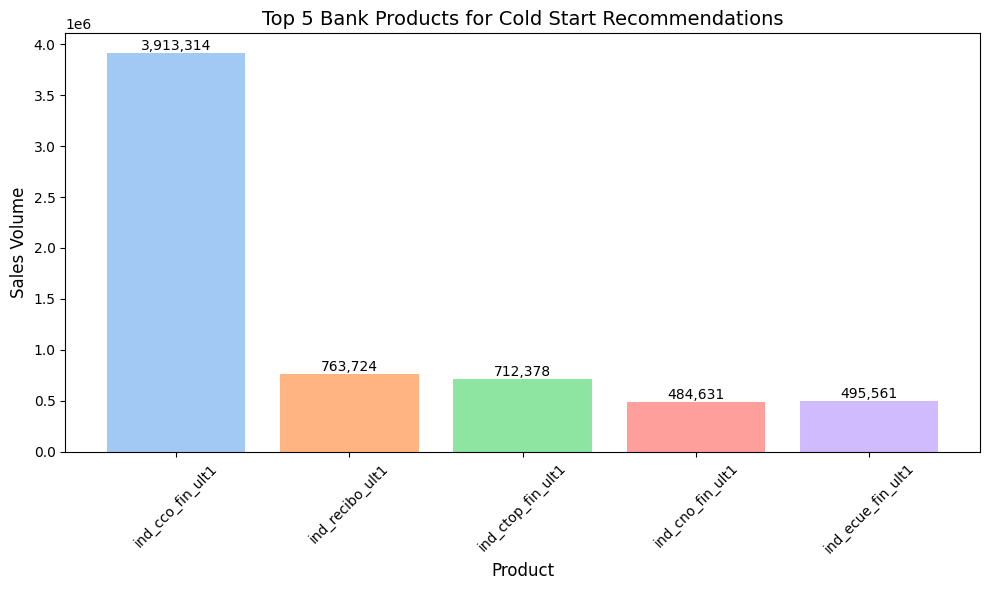

In [ ]:
# Data for the top 5 products
products = ['ind_cco_fin_ult1', 'ind_recibo_ult1', 'ind_ctop_fin_ult1', 'ind_cno_fin_ult1', 'ind_ecue_fin_ult1']
sales_volume = [3913314, 763724, 712378, 484631, 495561]

# Use a pastel color palette from Seaborn
colors = sns.color_palette("pastel", len(products))

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(products, sales_volume, color=colors)

# Add labels to each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Center the text
        bar.get_height(),                  # Position above the bar
        f"{bar.get_height():,}",           # Format as thousands with commas
        ha='center', va='bottom', fontsize=10
    )

# Chart customization
plt.xlabel('Product', fontsize=12)
plt.ylabel('Sales Volume', fontsize=12)
plt.title('Top 5 Bank Products for Cold Start Recommendations', fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()

# Display the chart
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import csv
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics.pairwise import cosine_similarity

import lightgbm as lgb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

pd.options.display.max_rows = 100
pd.options.display.max_columns = None

import math

import warnings
warnings.filterwarnings("ignore")

train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


# Data Cleaning and Preprocessing

In [ ]:

# Count duplicate rows
duplicate_count = train.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

duplicate_coun2t = test.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_coun2t}")

Number of duplicate rows: 0
Number of duplicate rows: 0


In [ ]:
train.info()
test.info()
train.describe(include = 'all').T
# Check missing values
train.isnull().sum()/train.shape[0] * 100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6440106 entries, 0 to 6440105
Data columns (total 48 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   fecha_dato             object 
 1   ncodpers               int64  
 2   ind_empleado           object 
 3   pais_residencia        object 
 4   sexo                   object 
 5   age                    int64  
 6   fecha_alta             object 
 7   ind_nuevo              int64  
 8   antiguedad             int64  
 9   indrel                 int64  
 10  ult_fec_cli_1t         object 
 11  indrel_1mes            object 
 12  tiprel_1mes            object 
 13  indresi                object 
 14  indext                 object 
 15  conyuemp               object 
 16  canal_entrada          object 
 17  indfall                object 
 18  tipodom                float64
 19  cod_prov               float64
 20  nomprov                object 
 21  ind_actividad_cliente  int64  
 22  renta             

,0
fecha_dato,0.000000
ncodpers,0.000000
ind_empleado,0.000000
pais_residencia,0.000000
sexo,0.000543
age,0.000000
fecha_alta,0.000000
ind_nuevo,0.000000
antiguedad,0.000000
indrel,0.000000


In [ ]:
## Inspect the data sample
train.sample(5)

,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,ult_fec_cli_1t,indrel_1mes,tiprel_1mes,indresi,indext,conyuemp,canal_entrada,indfall,tipodom,cod_prov,nomprov,ind_actividad_cliente,renta,segmento,ind_ahor_fin_ult1,ind_aval_fin_ult1,ind_cco_fin_ult1,ind_cder_fin_ult1,ind_cno_fin_ult1,ind_ctju_fin_ult1,ind_ctma_fin_ult1,ind_ctop_fin_ult1,ind_ctpp_fin_ult1,ind_deco_fin_ult1,ind_deme_fin_ult1,ind_dela_fin_ult1,ind_ecue_fin_ult1,ind_fond_fin_ult1,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
2699380,2016-01-28,1068251,N,ES,V,23,2012-09-26,0,40,1,NaN,1.0,I,S,N,NaN,KHD,N,1.0,36.0,PONTEVEDRA,1,160317.27,03 - UNIVERSITARIO,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2651987,2016-01-28,948984,N,ES,V,25,2011-09-26,0,52,1,NaN,1.0,A,S,N,NaN,KFA,N,1.0,28.0,MADRID,0,373437.42,02 - PARTICULARES,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4095021,2016-03-28,346602,N,ES,H,52,2003-07-24,0,168,1,NaN,1.0,I,S,N,NaN,KAB,N,1.0,50.0,ZARAGOZA,0,246189.81,02 - PARTICULARES,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6393073,2016-05-28,1148412,N,ES,H,22,2013-07-26,0,34,1,NaN,1.0,A,S,N,NaN,KHE,N,1.0,46.0,VALENCIA,1,62378.70,03 - UNIVERSITARIO,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2989948,2016-02-28,1419200,N,ES,V,20,2015-07-28,0,7,1,NaN,1,A,S,N,NaN,KHQ,N,1.0,26.0,"RIOJA, LA",1,63032.73,03 - UNIVERSITARIO,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Find the minimum and maximum dates
min_date = train['fecha_alta'].min()
max_date = train['fecha_alta'].max()

print(f"Minimum date: {min_date}")
print(f"Maximum date: {max_date}")


# Find the minimum and maximum dates
min_date = train['fecha_dato'].min()
max_date = train['fecha_dato'].max()

print(f"Minimum date: {min_date}")
print(f"Maximum date: {max_date}")



Minimum date: 2015-11-28 00:00:00
Maximum date: 2016-05-28 00:00:00


In [ ]:

# Ensure the fecha_dato column is in datetime format - train data
train['fecha_dato'] = pd.to_datetime(train['fecha_dato'])

# Find the minimum and maximum dates
min_date = train['fecha_dato'].min()
max_date = train['fecha_dato'].max()

print(f"Minimum date: {min_date}")
print(f"Maximum date: {max_date}")

# Ensure the fecha_dato column is in datetime format - test data
test['fecha_dato'] = pd.to_datetime(test['fecha_dato'])

# Find the minimum and maximum dates
min_date = test['fecha_dato'].min()
max_date = test['fecha_dato'].max()

print(f"Minimum date: {min_date}")
print(f"Maximum date: {max_date}")

# Mapping of Spanish column names to English
column_mapping = {
    'fecha_dato': 'data_date',
    'ncodpers': 'customer_code',
    'ind_empleado': 'employee_index',
    'pais_residencia': 'country_of_residence',
    'sexo': 'gender',
    'age': 'age',
    'fecha_alta': 'registration_date',
    'ind_nuevo': 'new_customer_index',
    'antiguedad': 'seniority',
    'indrel': 'customer_relationship',
    'ult_fec_cli_1t': 'last_date_primary_customer',
    'indrel_1mes': 'customer_type_start_month',
    'tiprel_1mes': 'relationship_type_start_month',
    'indresi': 'resident_index',
    'indext': 'foreigner_index',
    'conyuemp': 'spouse_index',
    'canal_entrada': 'joining_channel',
    'indfall': 'deceased_index',
    'tipodom': 'address_type',
    'cod_prov': 'province_code',
    'nomprov': 'province_name',
    'ind_actividad_cliente': 'activity_index',
    'renta': 'gross_income',
    'segmento': 'segment',
    'ind_ahor_fin_ult1': 'savings_account',
    'ind_aval_fin_ult1': 'guarantees',
    'ind_cco_fin_ult1': 'current_accounts',
    'ind_cder_fin_ult1': 'derivada_account',
    'ind_cno_fin_ult1': 'payroll_account',
    'ind_ctju_fin_ult1': 'junior_account',
    'ind_ctma_fin_ult1': 'mas_particular_account',
    'ind_ctop_fin_ult1': 'particular_account',
    'ind_ctpp_fin_ult1': 'particular_plus_account',
    'ind_deco_fin_ult1': 'short_term_deposits',
    'ind_deme_fin_ult1': 'medium_term_deposits',
    'ind_dela_fin_ult1': 'long_term_deposits',
    'ind_ecue_fin_ult1': 'e_account',
    'ind_fond_fin_ult1': 'funds',
    'ind_hip_fin_ult1': 'mortgage',
    'ind_plan_fin_ult1': 'pension_plan',
    'ind_pres_fin_ult1': 'loans',
    'ind_reca_fin_ult1': 'taxes',
    'ind_tjcr_fin_ult1': 'credit_card',
    'ind_valo_fin_ult1': 'securities',
    'ind_viv_fin_ult1': 'home_account',
    'ind_nomina_ult1': 'payroll',
    'ind_nom_pens_ult1': 'pensions',
    'ind_recibo_ult1': 'direct_debit',
}


test = pd.DataFrame(columns=[
    'fecha_dato', 'ncodpers', 'ind_empleado', 'pais_residencia', 'sexo', 'age',
    'fecha_alta', 'ind_nuevo', 'antiguedad', 'indrel', 'ult_fec_cli_1t',
    'indrel_1mes', 'tiprel_1mes', 'indresi', 'indext', 'conyuemp',
    'canal_entrada', 'indfall', 'tipodom', 'cod_prov', 'nomprov',
    'ind_actividad_cliente', 'renta', 'segmento'
])

# Renaming columns
test.rename(columns=column_mapping, inplace=True)

# Print the renamed DataFrame columns
print(test.columns)


# Data Cleaning
In this step, the cleaning process will include the following parts:

1) Column Names Conversion

2) Data Type Correction

3) Missing values imputation

4) Outliers Correction

In [ ]:
# 1) Feature Name Transformation
col_names = {"ncodpers":"cust_id", "ind_empleado":"emp_index","pais_residencia":"residence",
            "sexo":"sex","fecha_alta":"first_date","ind_nuevo":"new_cust","antiguedad":"seniority",
            "indrel":"is_primary","ult_fec_cli_1t":"last_primary_date","indrel_1mes":"cust_type",
            "tiprel_1mes":"cust_rel_type","indresi":"residence_index","indext":"foreigner_index",
            "conyuemp":"spouse_index","canal_entrada":"channel","cod_prov":"province","nomprov":"province_name",
            "ind_actividad_cliente":"active_index","renta":"income","segmento":"segment"}

train.rename(col_names, axis = 1, inplace = True)
test.rename(col_names, axis = 1, inplace = True)

# 2) Data Type Conversion
# Convert the features into their intuitive types
train.age = pd.to_numeric(train.age, errors='coerce')
train.income = pd.to_numeric(train.income, errors='coerce')
train.seniority = pd.to_numeric(train.seniority, errors='coerce')
train.first_date = pd.to_datetime(train.first_date, errors = 'coerce')
train['fecha_dato'] = pd.to_datetime(train['fecha_dato'])

test.age = pd.to_numeric(test.age, errors='coerce')
test.income = pd.to_numeric(test.income, errors='coerce')
test.seniority = pd.to_numeric(test.seniority, errors='coerce')
test.first_date = pd.to_datetime(test.first_date, errors = 'coerce')

test['fecha_dato'] = pd.to_datetime(test['fecha_dato'])


# 3) Missing values imputation

# For features with missing values percentage < 10%, use the most common factor level to impute
cols = ['emp_index','residence','sex','first_date','new_cust','is_primary',"cust_type","cust_rel_type",
       "province","province_name","active_index","channel","segment"]

for i in cols:
    train.loc[train[i].isnull(), i] = train[i].value_counts().index[0]
    test.loc[test[i].isnull(), i] = test[i].value_counts().index[0]

# For features with missing value accounts for over 10%, impute their missing values based on the mean at different dimensions
# For Income, impute the missings using the medians of Customer Segment and Province
train['income'].fillna(train['income'].mean(), inplace = True)
test['income'].fillna(test['income'].mean(), inplace = True)

# # Drop the last primary date and spouse index fields given over 99% missing values
# train.drop(['last_primary_date','spouse_index'], axis = 1, inplace = True)
# test.drop(['last_primary_date','spouse_index'], axis = 1, inplace = True)

# # Take a look at the cleaned data
# train.head()


In [ ]:
print(train[['fecha_dato', 'first_date']].sort_values(by='fecha_dato', ascending=False).head(5))

        fecha_dato first_date
6440105 2016-05-28 2016-05-13
5819118 2016-05-28 1995-01-16
5819144 2016-05-28 1995-01-16
5819143 2016-05-28 1995-01-16
5819142 2016-05-28 1995-01-16


   Customer_Type    Count
0            1.0  2612787
1            1.0  2392006
2              1  1430918
3            3.0     1137
4            3.0      892
5              3      748
6              P      540
7              2      321
8            2.0      314
9            2.0      241
10           4.0       96
11           4.0       67
12             4       39
   cust_id Recency_Type  Recency
0  1419117          NaN        7
1  1419128          NaN        7
2  1419118          NaN        7
3  1419120          NaN        7
4  1419122          NaN        7


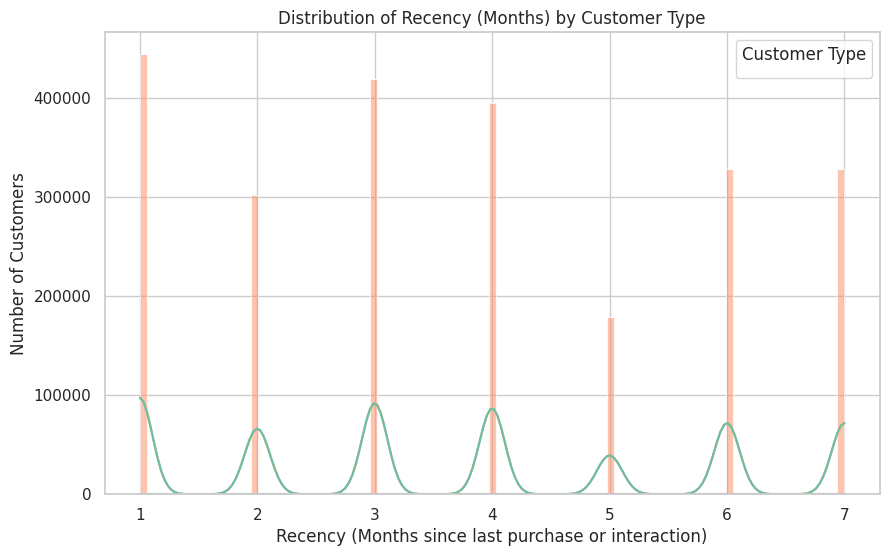

In [ ]:

# Assuming 'data' is DataFrame and 'fecha_dato' is the transaction date
data = train
# Define the fixed current date
current_date = pd.to_datetime('2016-06-28')

# Ensure 'fecha_dato' is in datetime format
data['fecha_dato'] = pd.to_datetime(data['fecha_dato'], errors='coerce')

# Calculate the difference in months (rounded to nearest month) for recency of customer type
data['Recency'] = (current_date - data['fecha_dato']).dt.days / 30  # Convert days to months
data['Recency'] = data['Recency'].round().astype('Int64')  # Round to nearest month and convert to integer

# Count the number of customers in each customer type (1, 2, 3, 4)
customer_type_counts = data['cust_type'].value_counts().reset_index()

# Rename columns for clarity
customer_type_counts.columns = ['Customer_Type', 'Count']

# Check the result
print(customer_type_counts)

# Map customer types to descriptive labels
data['Recency_Type'] = data['cust_type'].map({
    1: 'First/Primary',  # New/First customer
    2: 'Co-owner',       # Co-owner
    'P': 'Potential',    # Potential customer
    3: 'Former Primary', # Former primary customer
    4: 'Former Co-owner' # Former co-owner
})

# Print the recency and customer type for a few customers
print(data[['cust_id', 'Recency_Type', 'Recency']].head())


# Set the style for the plots
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))

# Plot a histogram for recency by customer type
sns.histplot(data=data, x='Recency', hue='Recency_Type', kde=True, multiple="stack", palette="Set2")

# Add a title and labels
plt.title('Distribution of Recency (Months) by Customer Type')
plt.xlabel('Recency (Months since last purchase or interaction)')
plt.ylabel('Number of Customers')
plt.legend(title='Customer Type')

# Display the plot
plt.show()


(13560, 3)


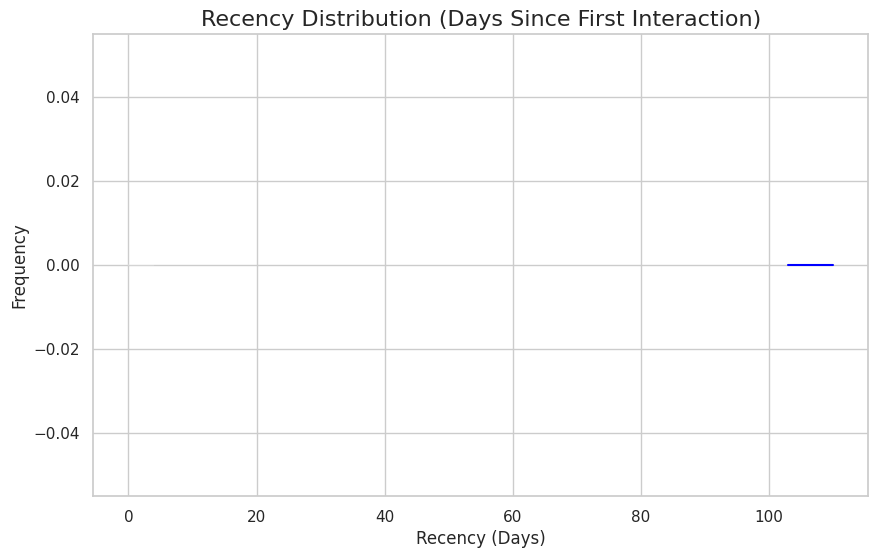

In [ ]:

data = train

# Ensure 'last_primary_date' is in datetime format
data['last_primary_date'] = pd.to_datetime(data['last_primary_date'], errors='coerce')

# Remove rows where 'last_primary_date' is missing (NaT)
data = data.dropna(subset=['last_primary_date'])

# Calculate the recency: number of months since the last primary interaction
current_date = pd.to_datetime('today')

# Calculate the difference in months (rounded to nearest month)
data['Recency'] = (current_date - data['last_primary_date']).dt.days / 30  # Convert days to months
data['Recency'] = data['Recency'].round().astype('Int64')  # Round to nearest month and convert to integer

# Check the result
print(data[['cust_id', 'last_primary_date', 'Recency']].shape)

# Set the style for the plots
sns.set(style="whitegrid")

bins = [0, 0.5, 1, 2, 3, 4]  # Custom bin edges
# Plotting Recency Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['Recency'], kde=True, color='blue', bins=bins)
plt.title('Recency Distribution (Days Since First Interaction)', fontsize=16)
plt.xlabel('Recency (Days)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()


Feature Engineering

In [ ]:
# 1) Age group: group the age for lifestages: young, adult, senior, elder
age_group = [0, 20, 45, 65, 100]
age_labels = ['young', 'adult', 'senior', 'elder']

train['age_grouped'] = pd.cut(train.age, bins = age_group, labels = age_labels)
test['agg_grouped'] = pd.cut(test.age, bins = age_group, labels = age_labels)

# 2) Income Group: group the incomes at Low, Ordinary, Median-high and High classes at (real case may be more complex)
train_income_group = [0, np.nanpercentile(train['income'], 25), np.nanpercentile(train['income'], 50), np.nanpercentile(train['income'], 75), np.nanpercentile(train['income'], 100)]
test_income_group = [0, np.nanpercentile(test['income'], 25), np.nanpercentile(test['income'], 50), np.nanpercentile(test['income'], 75), np.nanpercentile(test['income'], 100)]
income_labels = ['Low','Ordinary','Median-high','High']

train['income_grouped'] = pd.cut(train['income'], train_income_group, labels = income_labels)
test['income_grouped'] = pd.cut(test['income'], test_income_group, labels = income_labels)

## **RFM** Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data=train
# Convert relevant columns to datetime
data['fecha_dato'] = pd.to_datetime(data['fecha_dato'])
data['first_date'] = pd.to_datetime(data['first_date'])

# Remove rows with missing income (Monetary metric depends on income)
data = data.dropna(subset=['income'])

# Ensure 'age' and 'seniority' are numeric
data['age'] = pd.to_numeric(data['age'], errors='coerce')
data['seniority'] = pd.to_numeric(data['seniority'], errors='coerce')

# Recency: Days since the first interaction
data['Recency'] = (data['fecha_dato'].max() - data['first_date']).dt.days

#  not used - Frequency: Count of unique months a customer appears in the dataset
# frequency = data.groupby('cust_id')['fecha_dato'].nunique().reset_index()
# frequency.columns = ['cust_id', 'Frequency']

# Frequency: Count of unique months a customer appears in the dataset
# Step 1: Define product columns
product_columns = [col for col in data.columns if col.startswith('ind_')]
# Step 2: Count the number of products owned by each customer (frequency of products)
data['product_count'] = data[product_columns].sum(axis=1)
# Step 3: Group by 'cust_id' and calculate the number of unique dates (fecha_dato) per customer
frequency = data.groupby('cust_id')['fecha_dato'].nunique().reset_index()
# Step 4: Rename the column for frequency
frequency.columns = ['cust_id', 'Frequency']

# Monetary: Average income per customer
monetary = data.groupby('cust_id')['income'].mean().reset_index()
monetary.columns = ['cust_id', 'Monetary']

# Merge RFM metrics into one dataframe
rfm = data[['cust_id', 'Recency']].drop_duplicates()
rfm = rfm.merge(frequency, on='cust_id')
rfm = rfm.merge(monetary, on='cust_id')

# Scale Monetary to remove large outliers
rfm['Monetary'] = np.log1p(rfm['Monetary'])  # Log transformation



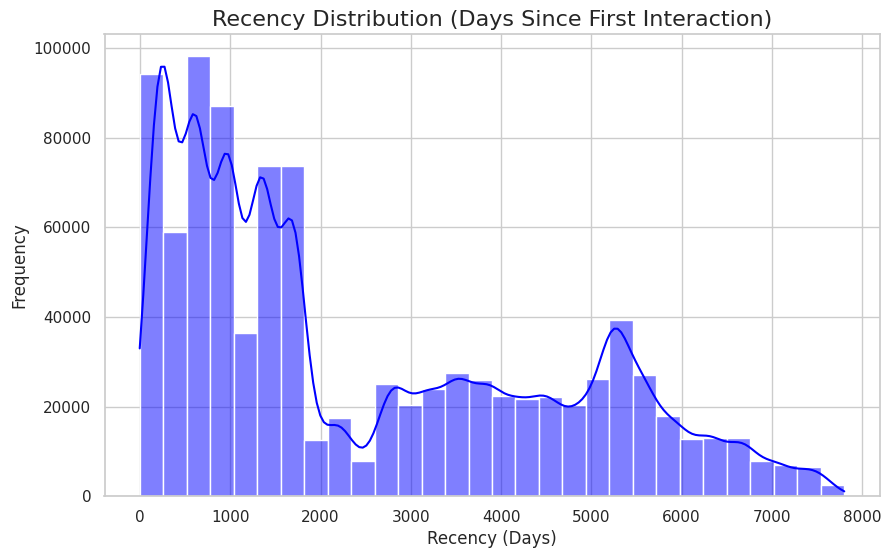

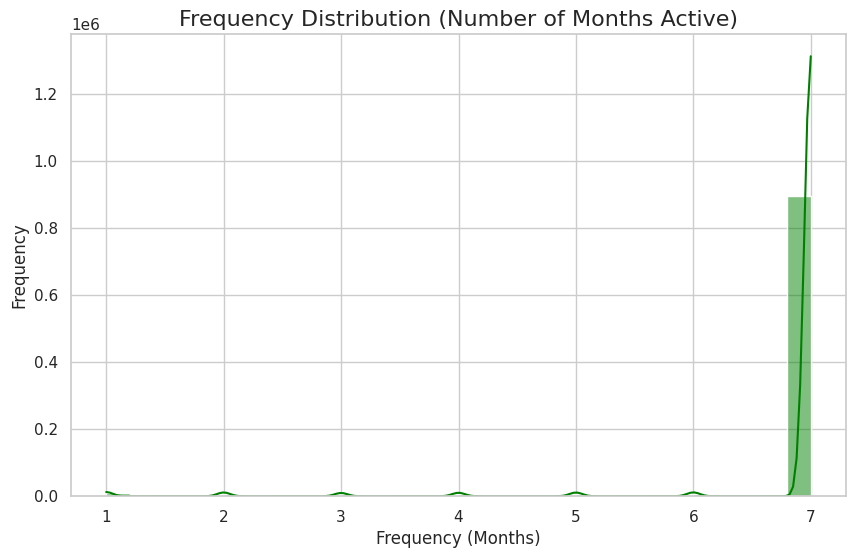

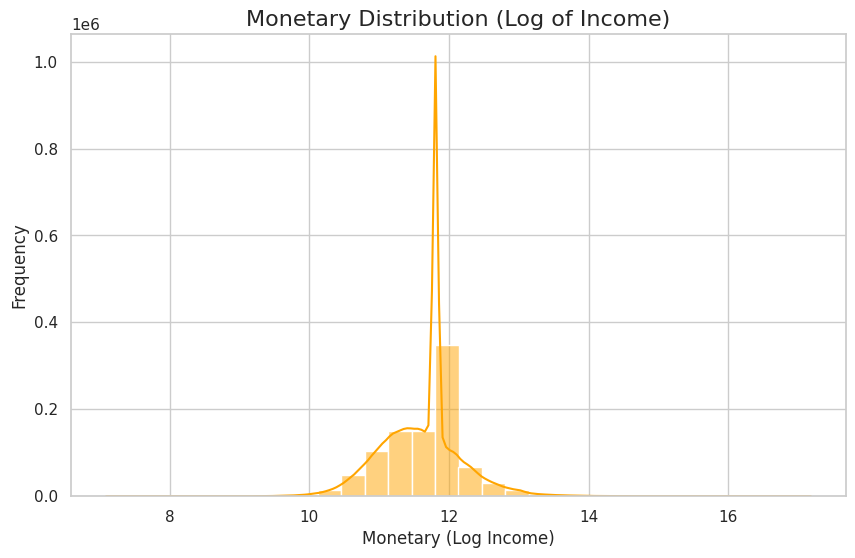

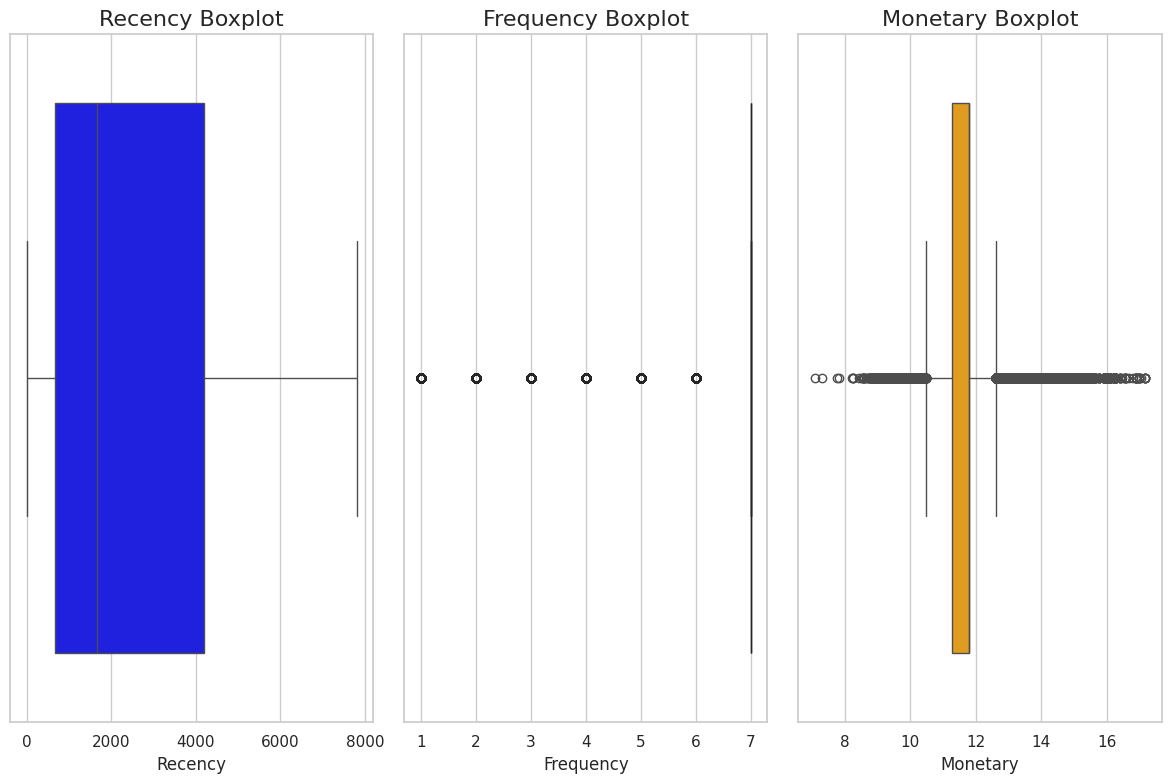

In [ ]:
# Set the style for the plots
sns.set(style="whitegrid")

# Plotting Recency Distribution
plt.figure(figsize=(10, 6))
sns.histplot(rfm['Recency'], kde=True, color='blue', bins=30)
plt.title('Recency Distribution (Days Since First Interaction)', fontsize=16)
plt.xlabel('Recency (Days)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Plotting Frequency Distribution
plt.figure(figsize=(10, 6))
sns.histplot(rfm['Frequency'], kde=True, color='green', bins=30)
plt.title('Frequency Distribution (Number of Months Active)', fontsize=16)
plt.xlabel('Frequency (Months)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Plotting Monetary Distribution
plt.figure(figsize=(10, 6))
sns.histplot(rfm['Monetary'], kde=True, color='orange', bins=30)
plt.title('Monetary Distribution (Log of Income)', fontsize=16)
plt.xlabel('Monetary (Log Income)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Optional: Boxplots for a better understanding of the data spread
plt.figure(figsize=(12, 8))

# Boxplot for Recency
plt.subplot(1, 3, 1)
sns.boxplot(x=rfm['Recency'], color='blue')
plt.title('Recency Boxplot', fontsize=16)

# Boxplot for Frequency
plt.subplot(1, 3, 2)
sns.boxplot(x=rfm['Frequency'], color='green')
plt.title('Frequency Boxplot', fontsize=16)

# Boxplot for Monetary
plt.subplot(1, 3, 3)
sns.boxplot(x=rfm['Monetary'], color='orange')
plt.title('Monetary Boxplot', fontsize=16)

plt.tight_layout()
plt.show()



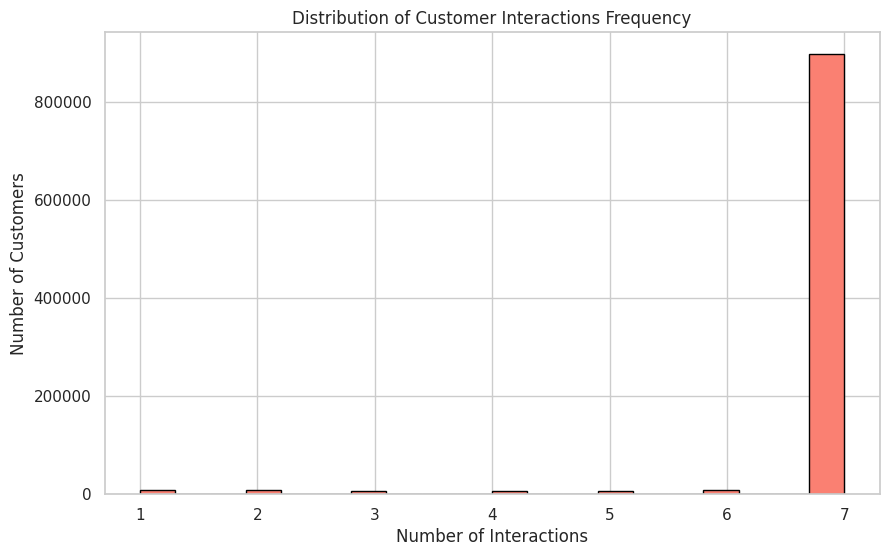

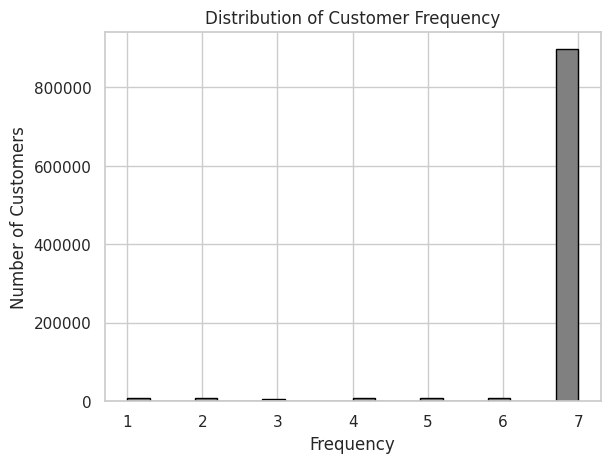

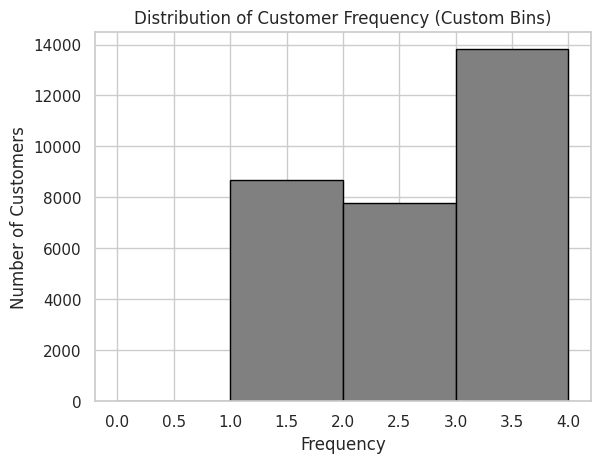

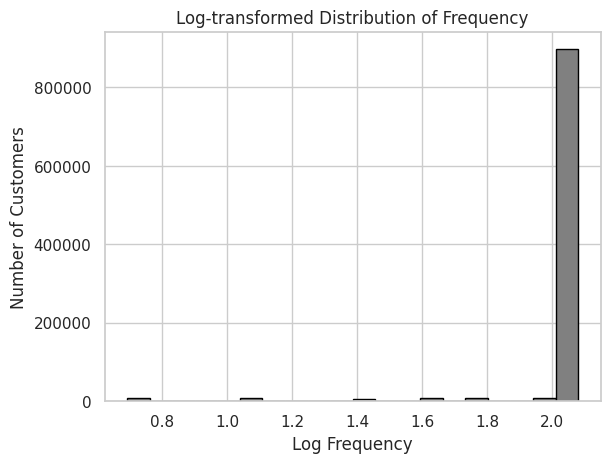

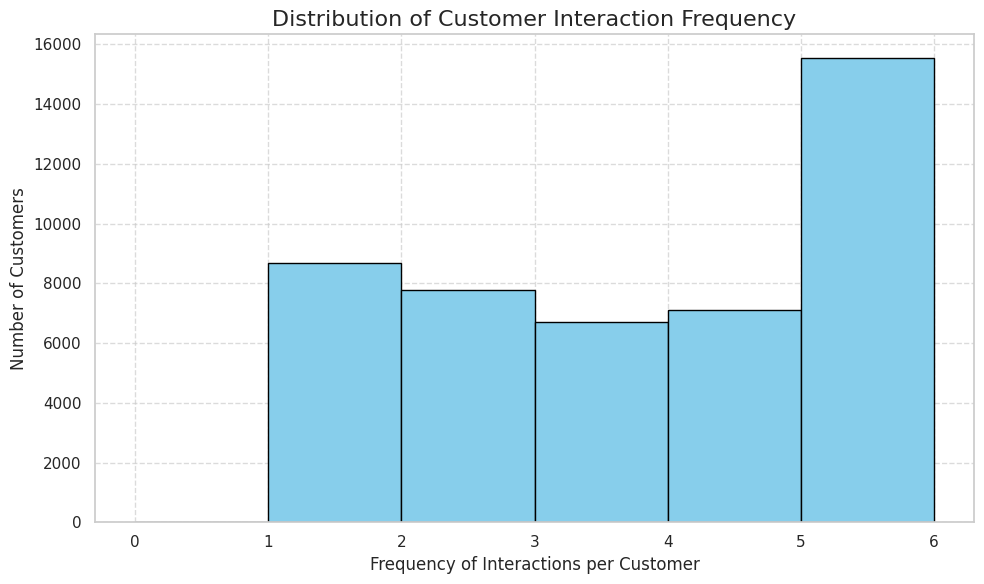

In [ ]:
# Plot a histogram for frequency of interactions per customer
plt.figure(figsize=(10, 6))
plt.hist(frequency['Frequency'], bins=20, color='salmon', edgecolor='black')
plt.title('Distribution of Customer Interactions Frequency')
plt.xlabel('Number of Interactions')
plt.ylabel('Number of Customers')
plt.grid(True)
plt.show()

plt.hist(frequency['Frequency'], bins=20, color='gray', edgecolor='black')  # Try with more bins
plt.title('Distribution of Customer Frequency')
plt.xlabel('Frequency')
plt.ylabel('Number of Customers')
plt.show()

bins = [0, 0.5, 1, 2, 3, 4]  # Custom bin edges
plt.hist(frequency['Frequency'], bins=bins, color='gray', edgecolor='black')
plt.title('Distribution of Customer Frequency (Custom Bins)')
plt.xlabel('Frequency')
plt.ylabel('Number of Customers')
plt.show()




frequency['Log_Frequency'] = frequency['Frequency'].apply(lambda x: np.log(x + 1))  # Add 1 to avoid log(0)
plt.hist(frequency['Log_Frequency'], bins=20, color='gray', edgecolor='black')
plt.title('Log-transformed Distribution of Frequency')
plt.xlabel('Log Frequency')
plt.ylabel('Number of Customers')
plt.show()

import matplotlib.pyplot as plt

# Define custom bin edges based on the data range and distribution.
bins = [0, 0.5, 1, 2, 3, 4,5,6]  # Custom bin edges that group interactions into different ranges

# Create the plot
plt.figure(figsize=(10, 6))

# Plot the histogram with custom bins
plt.hist(frequency['Frequency'], bins=bins, color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Distribution of Customer Interaction Frequency', fontsize=16)
plt.xlabel('Frequency of Interactions per Customer', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add grid lines for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()  # Ensures everything fits in the figure area
plt.show()



# SEGMENTS
#RFM BREAK EVEN

   cust_id  Recency  Frequency   Monetary Recency_quintile Frequency_quintile  \
0  1419117      305          7  10.873827                1                  1   
1  1419128      305          7  11.806306                1                  1   
2  1419118      305          7  11.035271                1                  1   
3  1419120      305          7  10.821136                1                  1   
4  1419122      305          7  10.354185                1                  1   

  Monetary_quintile RFM_Score  
0                 1       111  
1                 3       113  
2                 1       111  
3                 1       111  
4                 1       111  
        cust_id RFM_Score      Offer
614706  1379780       112  Product A
766258   905181       311  Product A
663787  1337219       113  Product A
73802    360959       515  Product A
918900  1524188       113  Product A
   RFM_Score  Response_Rate
0        111       0.100268
1        112       0.100104
2        113   

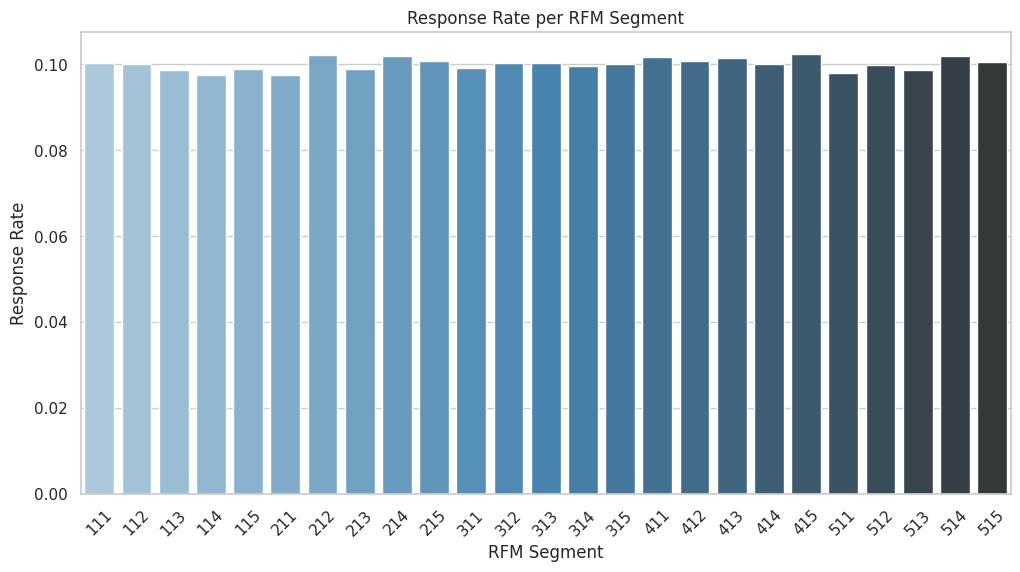

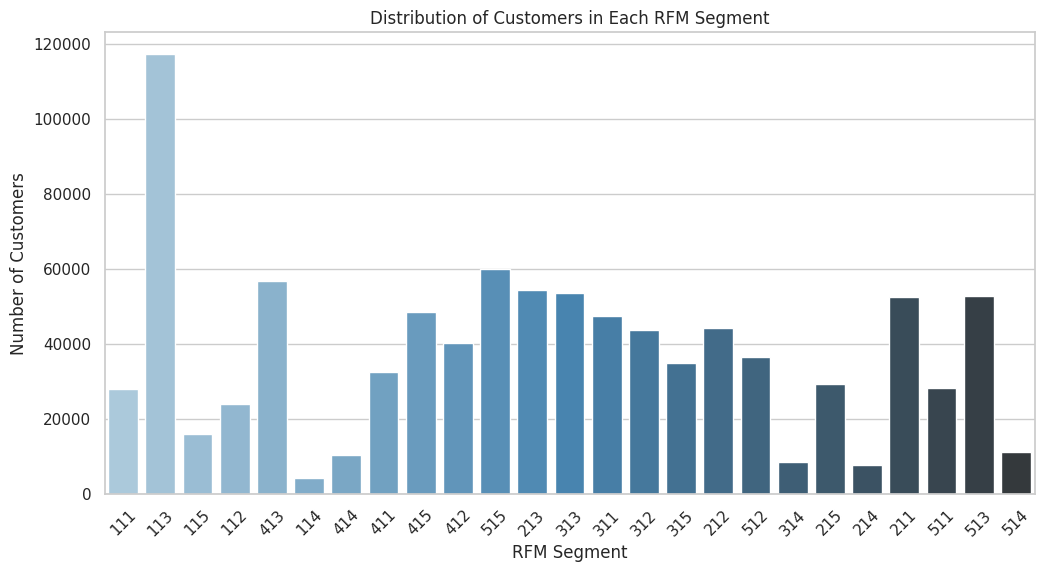

In [ ]:
import pandas as pd

# Assuming rfm has been created and has the 'Recency', 'Frequency', and 'Monetary' columns
def create_quintile_column(df, column_name, num_bins=5):
    # Use qcut and automatically handle fewer bins
    bins = pd.qcut(df[column_name], num_bins, labels=False, duplicates='drop')

    # Adjust the labels dynamically based on the number of unique bins
    unique_bins = len(bins.unique())
    labels = list(range(1, unique_bins + 1))

    # Use the dynamically adjusted labels
    df[column_name + '_quintile'] = pd.qcut(df[column_name], num_bins, labels=labels, duplicates='drop')
    return df

# Create quintiles for each column
rfm = create_quintile_column(rfm, 'Recency')
rfm = create_quintile_column(rfm, 'Frequency')
rfm = create_quintile_column(rfm, 'Monetary')

# Combine the quintiles into a single RFM score
rfm['RFM_Score'] = rfm['Recency_quintile'].astype(str) + rfm['Frequency_quintile'].astype(str) + rfm['Monetary_quintile'].astype(str)

# View the first few rows of the RFM dataframe
print(rfm.head())
# Create a random sample of customers from the RFM dataframe
sample_customers = rfm.sample(frac=0.1, random_state=42)  # Randomly select 10% of the customers
sample_customers['Offer'] = 'Product A'  # Example offer for the selected customers

# View the first few rows of the sample customers
print(sample_customers[['cust_id', 'RFM_Score', 'Offer']].head())

response_data = pd.merge(rfm, sample_customers[['cust_id', 'Offer']], on='cust_id', how='left')
response_data['response'] = response_data['Offer'].apply(lambda x: 1 if x == 'Product A' else 0)

# Calculate the response rate for each RFM segment
response_rate_per_segment = response_data.groupby('RFM_Score')['response'].mean().reset_index()
response_rate_per_segment.columns = ['RFM_Score', 'Response_Rate']

# View the response rate for each RFM segment
print(response_rate_per_segment)
# Define cost and profit per customer
cost_of_offer = 50
profit_per_customer = 200

# Calculate break-even response rate
break_even_response_rate = cost_of_offer / profit_per_customer

# Print the break-even response rate
print(f"Break-even response rate: {break_even_response_rate:.2f}")


# Filter RFM segments that have a response rate above the break-even response rate
segments_above_break_even = response_rate_per_segment[response_rate_per_segment['Response_Rate'] > break_even_response_rate]

# View the segments above break-even
print(segments_above_break_even)


# Merge back with the RFM dataframe to identify customers in the above break-even segments
target_customers = rfm[rfm['RFM_Score'].isin(segments_above_break_even['RFM_Score'])]

# Add the offer to these customers
target_customers['Offer'] = 'Product A'

# View the first few rows of customers who will receive the offer
print(target_customers[['cust_id', 'RFM_Score', 'Offer']].head())

# Plot the response rate per RFM segment
plt.figure(figsize=(12, 6))
sns.barplot(x='RFM_Score', y='Response_Rate', data=response_rate_per_segment, palette='Blues_d')
plt.title('Response Rate per RFM Segment')
plt.xlabel('RFM Segment')
plt.ylabel('Response Rate')
plt.xticks(rotation=45)
plt.show()


# Plot the distribution of customers in each RFM segment
plt.figure(figsize=(12, 6))
sns.countplot(x='RFM_Score', data=rfm, palette='Blues_d')
plt.title('Distribution of Customers in Each RFM Segment')
plt.xlabel('RFM Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

In [ ]:

col_names = {"ncodpers":"cust_id", "ind_empleado":"emp_index","pais_residencia":"residence",
            "sexo":"sex","fecha_alta":"first_date","ind_nuevo":"new_cust","antiguedad":"seniority",
            "indrel":"is_primary","ult_fec_cli_1t":"last_primary_date","indrel_1mes":"cust_type",
            "tiprel_1mes":"cust_rel_type","indresi":"residence_index","indext":"foreigner_index",
            "conyuemp":"spouse_index","canal_entrada":"channel","cod_prov":"province","nomprov":"province_name",
            "ind_actividad_cliente":"active_index","renta":"income","segmento":"segment"}

# Ensure 'fecha_alta' is in datetime format
data['first_date'] = pd.to_datetime(data['first_date'], errors='coerce')

# Calculate recency based on the first date of the customer (fecha_alta)
# Get the current date (today or maximum date in the dataset)
current_date = pd.to_datetime('today')

# Calculate the difference in months (rounded to nearest month)
data['Recency'] = (current_date - data['first_date']).dt.days / 30  # Convert days to months
data['Recency'] = data['Recency'].round().astype('Int64')  # Round to nearest month and convert to integer

# If 'fecha_alta' is NaT (missing date), assign a large number (e.g., 9999 months)
data['Recency'] = data['Recency'].fillna(9999)

# Assuming 'antiguedad' is already in months
data['Recency'] = data['seniority'].fillna(9999)

 # Set the style for the plots
sns.set(style="whitegrid")

# Plotting Recency Distribution
plt.figure(figsize=(10, 6))
sns.histplot(rfm['Recency'], kde=True, color='blue', bins=30)
plt.title('Recency Distribution (Days Since First Interaction)', fontsize=16)
plt.xlabel('Recency (Days)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()


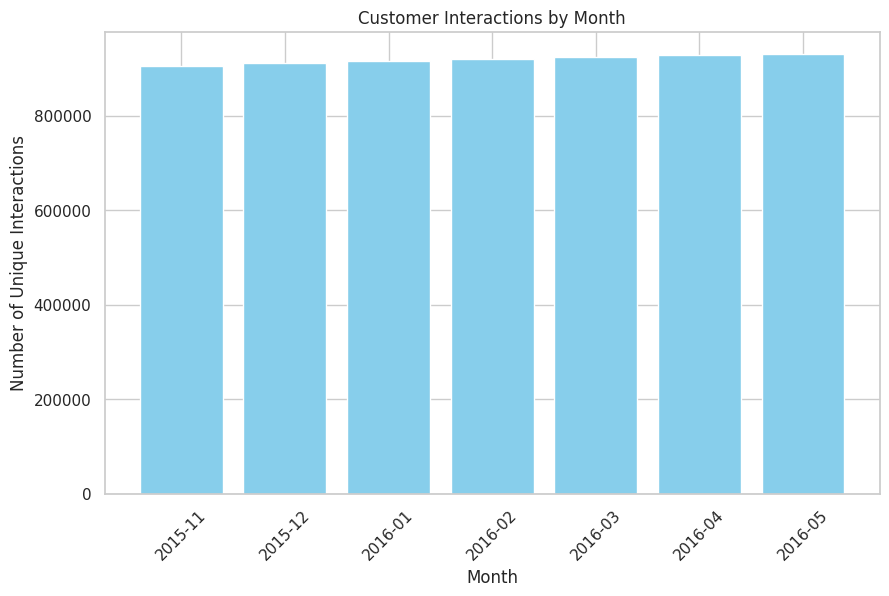

In [ ]:
# Group by month and count unique customer interactions per month
data['month_year'] = data['fecha_dato'].dt.to_period('M')
monthly_interactions = data.groupby('month_year')['cust_id'].nunique().reset_index()
monthly_interactions.columns = ['Month', 'customer_interactions']

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(monthly_interactions['Month'].astype(str), monthly_interactions['customer_interactions'], color='skyblue')
plt.title('Customer Interactions by Month')
plt.xlabel('Month')
plt.ylabel('Number of Unique Interactions')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


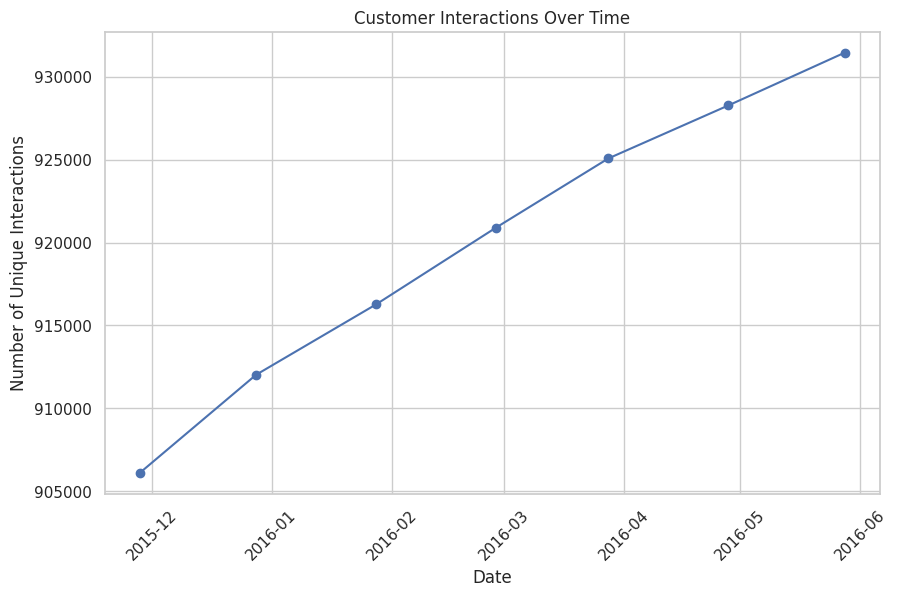

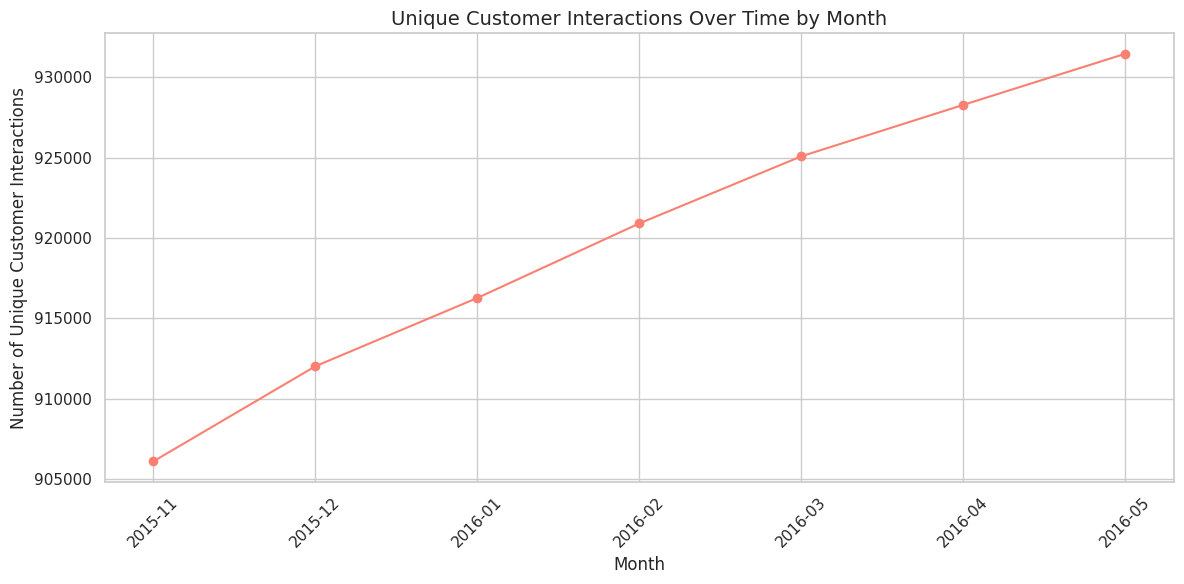

In [ ]:
# Assuming 'frequency' dataframe is already created (cust_id and Frequency)
# Convert 'fecha_dato' to datetime
data['fecha_dato'] = pd.to_datetime(data['fecha_dato'])

# Group by date to get the number of unique customers interacting each day
interaction_by_date = data.groupby('fecha_dato')['cust_id'].nunique().reset_index()
interaction_by_date.columns = ['fecha_dato', 'customer_interactions']

# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(interaction_by_date['fecha_dato'], interaction_by_date['customer_interactions'], marker='o', color='b')
plt.title('Customer Interactions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Unique Interactions')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


import matplotlib.pyplot as plt

# Step 1: Extract the month and year from the date
data['month'] = data['fecha_dato'].dt.to_period('M')  # Convert to month-period (e.g., '2015-11')

# Step 2: Group by month and count distinct customers interacting in each month
monthly_interactions = data.groupby('month')['cust_id'].nunique().reset_index()

# Step 3: Rename the columns for clarity
monthly_interactions.columns = ['Month', 'Unique Customer Interactions']

# Step 4: Plot the results
plt.figure(figsize=(12, 6))
plt.plot(monthly_interactions['Month'].astype(str), monthly_interactions['Unique Customer Interactions'], marker='o', color='salmon')

# Adding titles and labels
plt.title('Unique Customer Interactions Over Time by Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Unique Customer Interactions', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


# K-means clustering

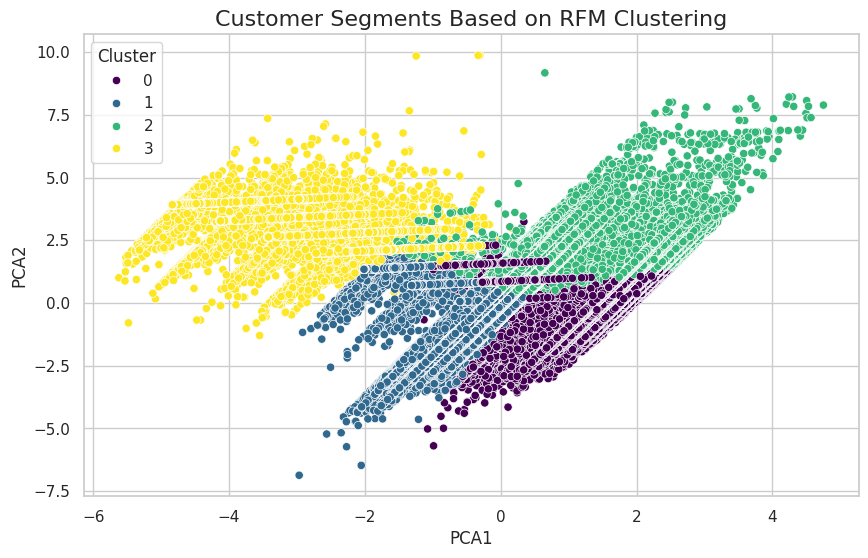

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Normalize RFM metrics
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Visualize clusters using PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(rfm_scaled)
rfm['PCA1'] = pca_result[:, 0]
rfm['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=rfm, palette='viridis')
plt.title('Customer Segments Based on RFM Clustering', fontsize=16)
plt.show()





   Recency  Frequency   Monetary  Cluster          Segment
0      305          7  10.873827        1  Loyal Customers
1      305          7  11.806306        1  Loyal Customers
2      305          7  11.035271        1  Loyal Customers
3      305          7  10.821136        1  Loyal Customers
4      305          7  10.354185        1  Loyal Customers
Segment
Loyal Customers            507865
High-Value Customers       276365
At-Risk Customers          128730
New/Low-Value Customers     30227
Name: count, dtype: int64


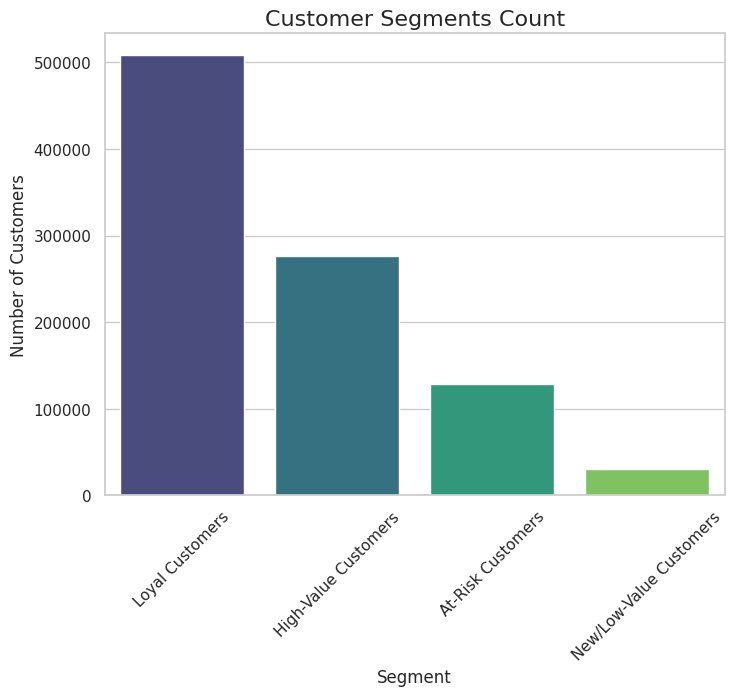

In [ ]:
# Map cluster labels to meaningful segment names
def label_clusters(row):
    if row['Cluster'] == 0:
        return 'High-Value Customers'
    elif row['Cluster'] == 1:
        return 'Loyal Customers'
    elif row['Cluster'] == 2:
        return 'At-Risk Customers'
    elif row['Cluster'] == 3:
        return 'New/Low-Value Customers'
    else:
        return 'Unknown'

# Apply the labeling function
rfm['Segment'] = rfm.apply(label_clusters, axis=1)

# Display the first few rows to verify
print(rfm[['Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].head())

# Optional: Count customers in each segment
segment_counts = rfm['Segment'].value_counts()
print(segment_counts)

# Visualize the counts of each segment
plt.figure(figsize=(8, 6))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')
plt.title('Customer Segments Count', fontsize=16)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.show()


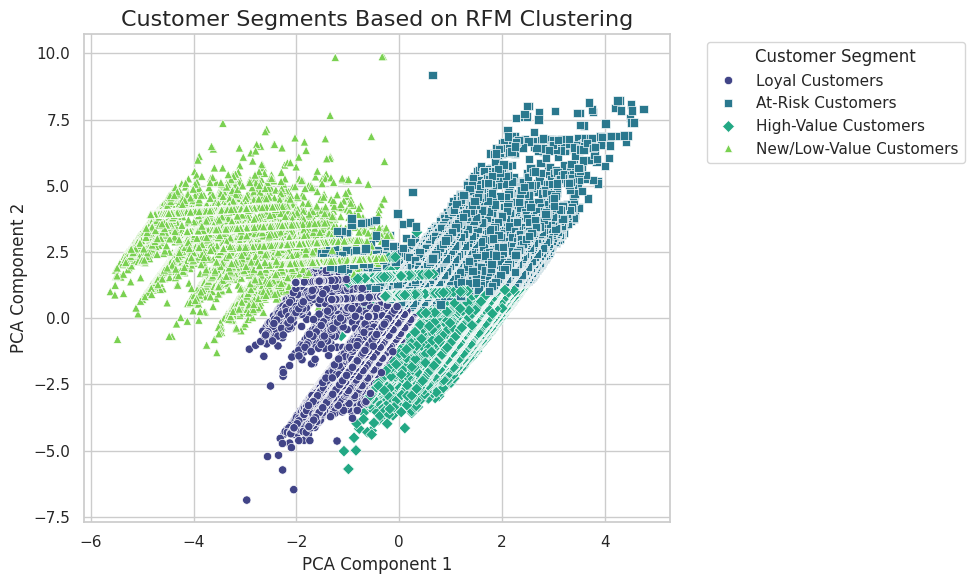

In [ ]:
# Scatter plot using PCA components with segment names as labels
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Segment',
    data=rfm,
    palette='viridis',
    style='Segment',
    markers=["o", "s", "D", "^"]  # Unique markers for each segment
)
plt.title('Customer Segments Based on RFM Clustering', fontsize=16)
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


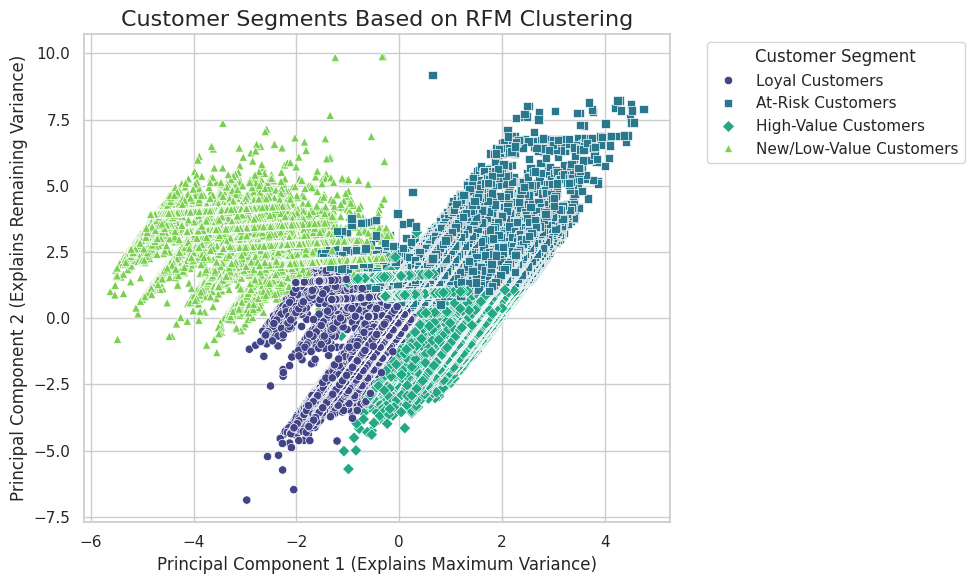

In [ ]:
# Scatter plot using PCA components with custom axis labels and segment names as labels
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Segment',
    data=rfm,
    palette='viridis',
    style='Segment',
    markers=["o", "s", "D", "^"]  # Unique markers for each segment
)

# Update axis labels with custom names
plt.title('Customer Segments Based on RFM Clustering', fontsize=16)
plt.xlabel('Principal Component 1 (Explains Maximum Variance)', fontsize=12)
plt.ylabel('Principal Component 2 (Explains Remaining Variance)', fontsize=12)

# Customize the legend and layout
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


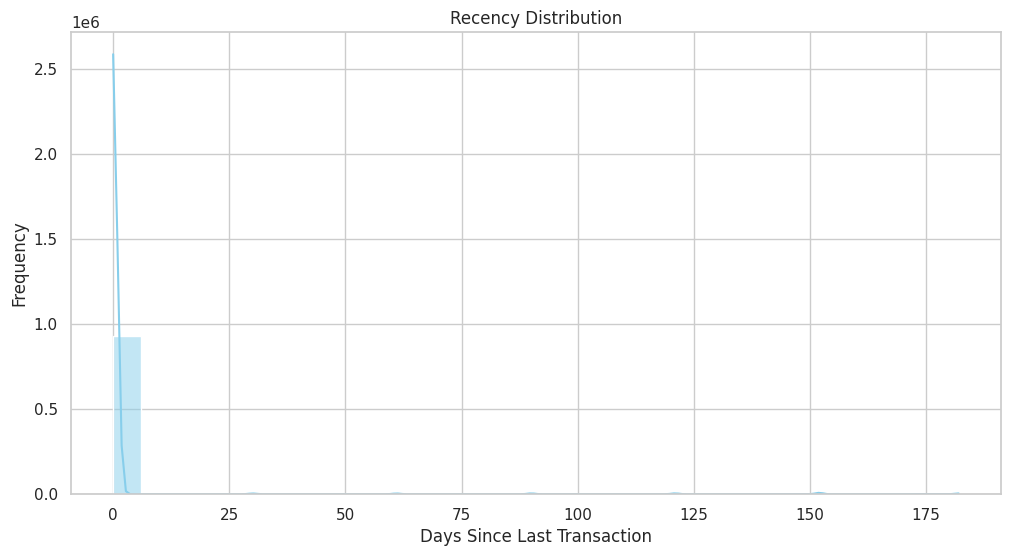

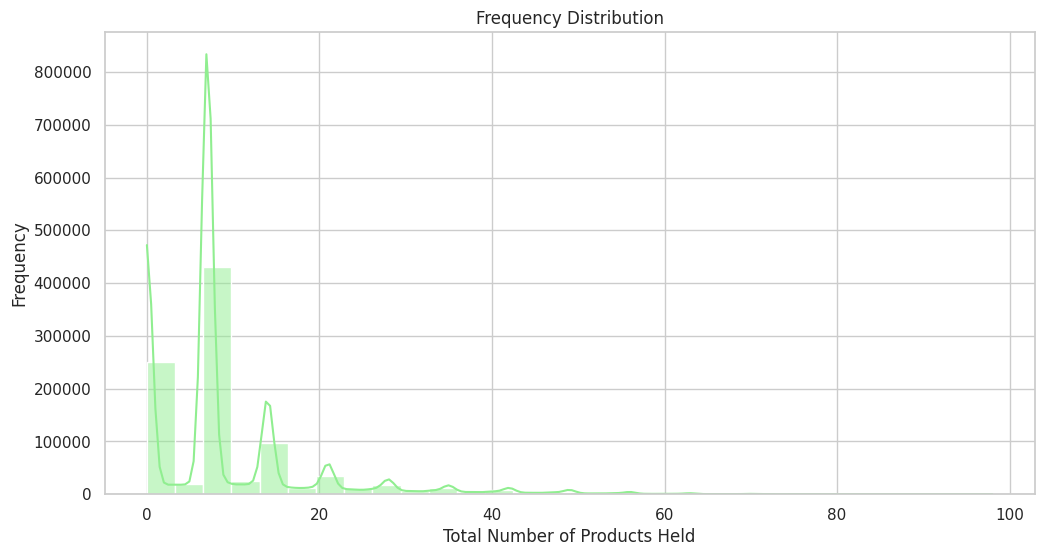

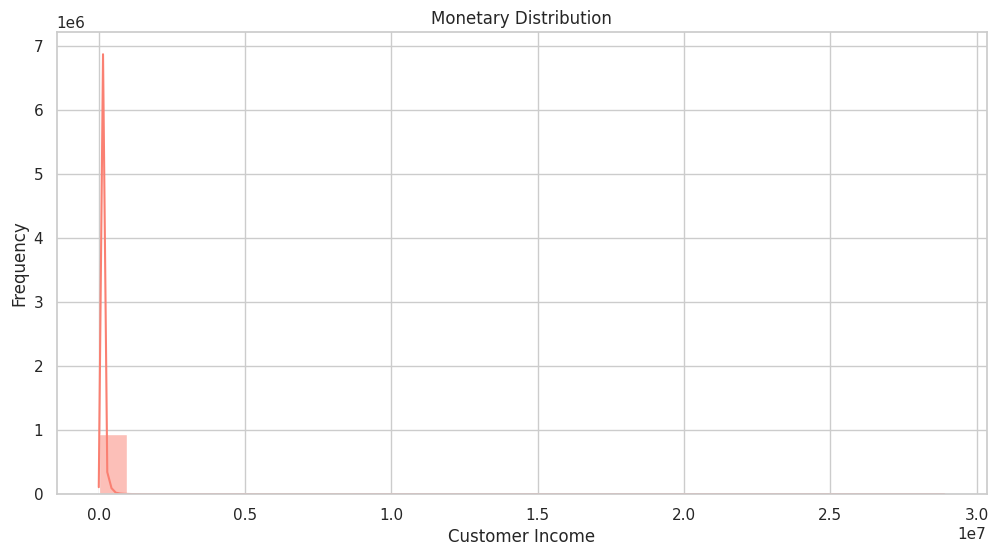

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'fecha_dato' is the transaction date, 'cust_id' is the customer ID,
# and 'income' is the monetary value (gross income of the customer).
# Also assuming product columns (ind_ahor_fin_ult1, etc.) are available.

# Convert fecha_dato to datetime
train['fecha_dato'] = pd.to_datetime(train['fecha_dato'])

# Calculate Recency: days since last transaction for each customer
max_date = train['fecha_dato'].max()
train['Recency'] = (max_date - train.groupby('cust_id')['fecha_dato'].transform('max')).dt.days

# Calculate Frequency: count the number of products held by each customer
product_columns = [
    "ind_ahor_fin_ult1", "ind_aval_fin_ult1", "ind_cco_fin_ult1",
    "ind_cder_fin_ult1", "ind_cno_fin_ult1", "ind_ctju_fin_ult1",
    "ind_ctma_fin_ult1", "ind_ctop_fin_ult1", "ind_ctpp_fin_ult1",
    "ind_deco_fin_ult1", "ind_deme_fin_ult1", "ind_dela_fin_ult1",
    "ind_ecue_fin_ult1", "ind_fond_fin_ult1", "ind_hip_fin_ult1",
    "ind_plan_fin_ult1", "ind_pres_fin_ult1", "ind_reca_fin_ult1",
    "ind_tjcr_fin_ult1", "ind_valo_fin_ult1", "ind_viv_fin_ult1",
    "ind_nomina_ult1", "ind_nom_pens_ult1", "ind_recibo_ult1"
]

train['Frequency'] = train[product_columns].sum(axis=1)

# Calculate Monetary: income for each customer (assuming 'income' column represents monetary value)
train['Monetary'] = train['income']

# Aggregate the data by cust_id to get the RFM values for each customer
rfm_df = train.groupby('cust_id').agg({
    'Recency': 'min',  # Recency: most recent transaction
    'Frequency': 'sum',  # Frequency: total number of products held
    'Monetary': 'mean'  # Monetary: average income
}).reset_index()

# Step 3: Visualize the RFM Components

# Recency Distribution
plt.figure(figsize=(12, 6))
sns.histplot(rfm_df['Recency'], kde=True, color='skyblue', bins=30)
plt.title('Recency Distribution')
plt.xlabel('Days Since Last Transaction')
plt.ylabel('Frequency')
plt.show()

# Frequency Distribution
plt.figure(figsize=(12, 6))
sns.histplot(rfm_df['Frequency'], kde=True, color='lightgreen', bins=30)
plt.title('Frequency Distribution')
plt.xlabel('Total Number of Products Held')
plt.ylabel('Frequency')
plt.show()

# Monetary Distribution
plt.figure(figsize=(12, 6))
sns.histplot(rfm_df['Monetary'], kde=True, color='salmon', bins=30)
plt.title('Monetary Distribution')
plt.xlabel('Customer Income')
plt.ylabel('Frequency')
plt.show()

# RFM analaysis - Visualizations for Recency, Frequency, and Monetary

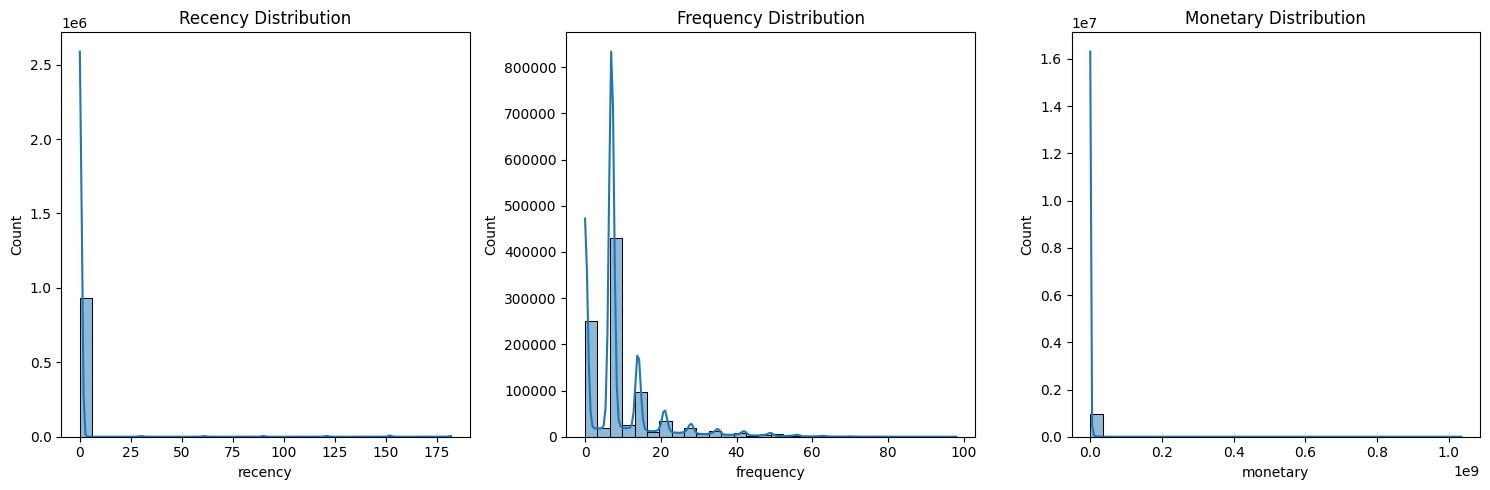

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = train


# Convert date columns to datetime
df['fecha_dato'] = pd.to_datetime(df['fecha_dato'])

# 1. Calculate Recency (R)
# Get the current date (2016-06-28) and calculate Recency based on the last purchase (up to 2016-05-28)
last_date = pd.to_datetime('2016-05-28')
df['recency'] = (last_date - df['fecha_dato']).dt.days

# 2. Calculate Frequency (F)
# Frequency: Count of products held by the customer as of May 28, 2016 (the columns from ind_ahor_fin_ult1 to ind_recibo_ult1)
product_columns = [col for col in df.columns if col.startswith('ind_')]
df['product_count'] = df[product_columns].sum(axis=1)

# Frequency: Repeat purchases of certain product types (customers who frequently engage with particular products)
# Count frequency of purchases from the product columns
df['frequency'] = df[product_columns].sum(axis=1)  # Number of products owned by the customer

# 3. Calculate Monetary (M)
# Monetary: Use a proxy for monetary value (e.g., income * number of products)
df['monetary'] = df['income'] * df['product_count']

# Aggregate RFM values for each customer (assuming 'cust_id' is the customer ID)
rfm = df.groupby('cust_id').agg({
    'recency': 'min',  # Min recency for each customer (last activity)
    'frequency': 'sum',  # Total number of products owned (frequency of product engagement)
    'monetary': 'sum'  # Total monetary value based on income and products owned
}).reset_index()

# 4. Prepare for product prediction (Additional Products to Buy in June 2016)
# To predict products customers will buy, we need to identify products owned in May 2016 and predict which they will acquire in June 2016

# Visualizations for Recency, Frequency, and Monetary
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recency histogram
sns.histplot(rfm['recency'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Recency Distribution')

# Frequency histogram
sns.histplot(rfm['frequency'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Frequency Distribution')

# Monetary histogram
sns.histplot(rfm['monetary'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

# The variable of interest in this context is **which products** a customer will buy between May 28 and June 28, 2016.
# Thus, we'll focus on identifying the patterns in the historical data that predict **future product purchases**.



## RFM - ANALSYSIS - WITH ALL DATA

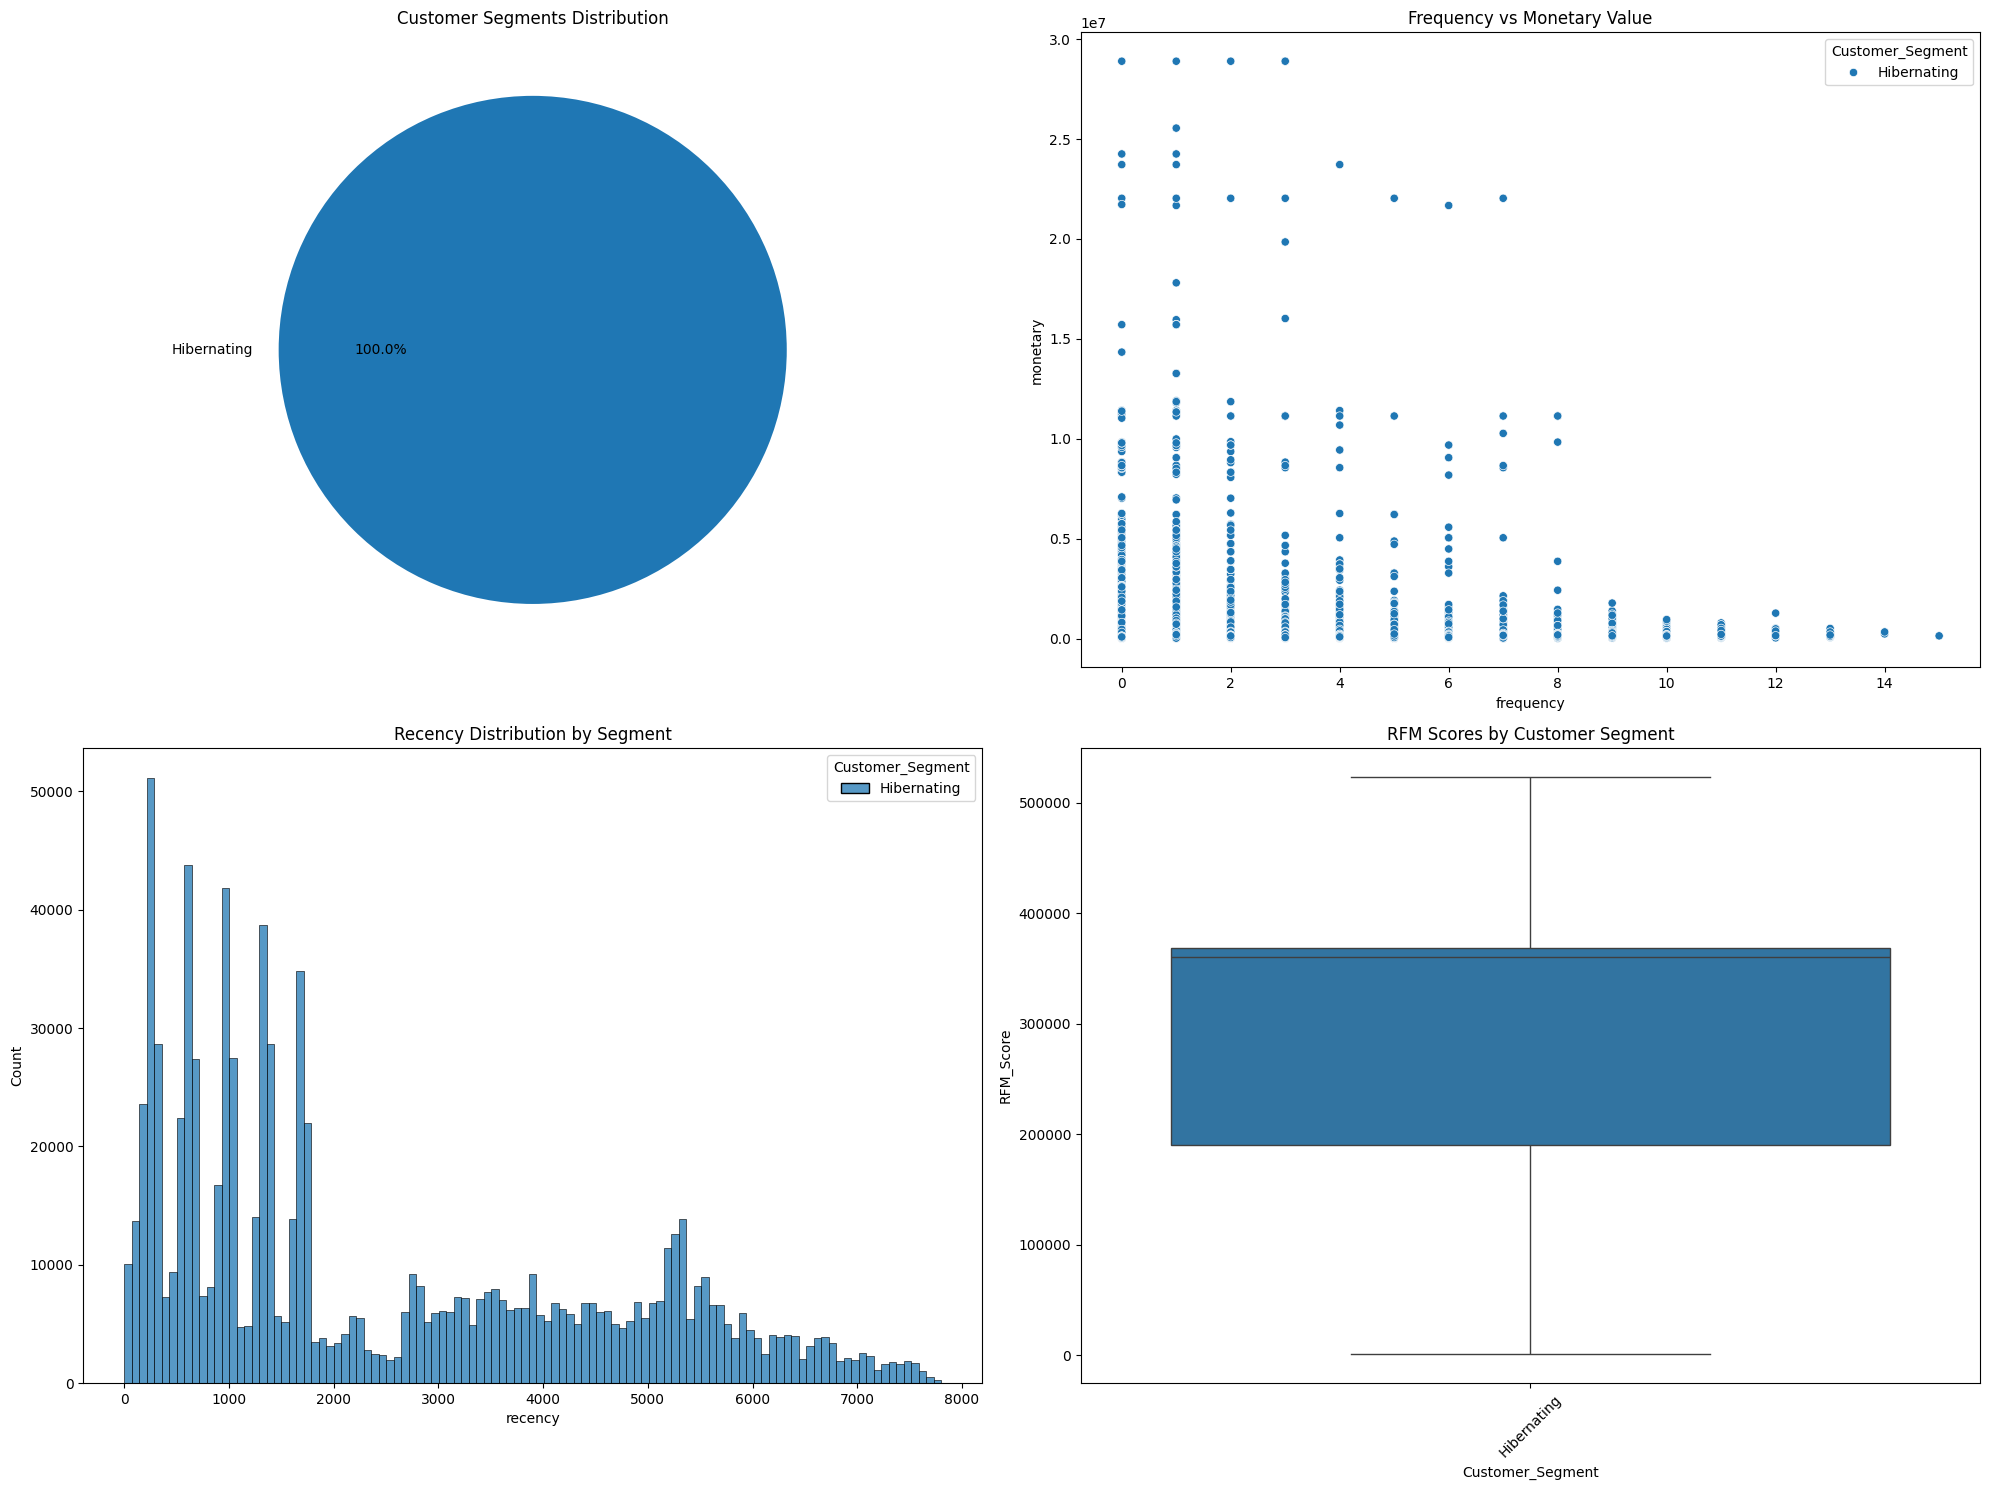


Customer Segment Summary:
                  Customer_Count      recency  frequency       monetary
Customer_Segment                                                       
Hibernating               931453  2491.891638   1.331831  134090.780588


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def perform_rfm_analysis(df):
    # Identify the most recent date in the dataset
    latest_date = df['fecha_dato'].max()

    # Calculate Recency (days since last transaction)
    recency_df = df[df['fecha_dato'] == latest_date].copy()
    recency_df['recency'] = (latest_date - recency_df['first_date']).dt.days

    # Calculate Frequency (number of products)
    product_columns = [col for col in df.columns if col.startswith('ind_') and col.endswith('_ult1')]
    recency_df['frequency'] = recency_df[product_columns].sum(axis=1)

    # Calculate Monetary Value (using income as a proxy)
    recency_df['monetary'] = recency_df['income']

    # Rank RFM metrics
    recency_df['R_rank'] = recency_df['recency'].rank(method='dense', ascending=False)
    recency_df['F_rank'] = recency_df['frequency'].rank(method='dense')
    recency_df['M_rank'] = recency_df['monetary'].rank(method='dense')

    # Calculate RFM Score
    recency_df['RFM_Score'] = recency_df['R_rank'] + recency_df['F_rank'] + recency_df['M_rank']

    # Segment Customers
    def segment_customers(score):
        if score <= 3: return 'Champions'
        elif score <= 6: return 'Potential Loyalists'
        elif score <= 9: return 'At Risk Customers'
        else: return 'Hibernating'

    recency_df['Customer_Segment'] = recency_df['RFM_Score'].apply(segment_customers)

    # Visualizations
    plt.figure(figsize=(20,15))

    # 1. Customer Segments Distribution
    plt.subplot(2,2,1)
    segment_counts = recency_df['Customer_Segment'].value_counts()
    plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%')
    plt.title('Customer Segments Distribution')

    # 2. Frequency vs Monetary Scatter Plot
    plt.subplot(2,2,2)
    sns.scatterplot(data=recency_df, x='frequency', y='monetary', hue='Customer_Segment')
    plt.title('Frequency vs Monetary Value')

    # 3. Recency Distribution
    plt.subplot(2,2,3)
    sns.histplot(data=recency_df, x='recency', hue='Customer_Segment', multiple='stack')
    plt.title('Recency Distribution by Segment')

    # 4. RFM Score Box Plot
    plt.subplot(2,2,4)
    sns.boxplot(x='Customer_Segment', y='RFM_Score', data=recency_df)
    plt.title('RFM Scores by Customer Segment')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    # Summary Statistics
    summary = recency_df.groupby('Customer_Segment').agg({
        'cust_id': 'count',
        'recency': 'mean',
        'frequency': 'mean',
        'monetary': 'mean'
    }).rename(columns={'cust_id': 'Customer_Count'})

    return recency_df, summary

# Perform RFM Analysis
rfm_results, segment_summary = perform_rfm_analysis(train)

# Print Summary Statistics
print("\nCustomer Segment Summary:")
print(segment_summary)

# Optional: Export results
rfm_results.to_csv('rfm_analysis_results.csv', index=False)
segment_summary.to_csv('rfm_segment_summary.csv')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def perform_rfm_analysis(df):
    # Identify the most recent date in the dataset
    latest_date = df['fecha_dato'].max()

    # Calculate Recency (days since last transaction)
    recency_df = df[df['fecha_dato'] == latest_date].copy()
    recency_df['recency'] = (latest_date - recency_df['first_date']).dt.days

    # Calculate Frequency (number of products)
    product_columns = [col for col in df.columns if col.startswith('ind_') and col.endswith('_ult1')]
    recency_df['frequency'] = recency_df[product_columns].sum(axis=1)

    # Calculate Monetary Value (using income as a proxy)
    recency_df['monetary'] = recency_df['income']

    # Perform quartile-based ranking for more nuanced segmentation
    recency_df['R_quartile'] = pd.qcut(recency_df['recency'], q=4, labels=[4,3,2,1])
    recency_df['F_quartile'] = pd.qcut(recency_df['frequency'], q=4, labels=[1,2,3,4])
    recency_df['M_quartile'] = pd.qcut(recency_df['monetary'], q=4, labels=[1,2,3,4])

    # Create detailed customer segments
    def advanced_segmentation(row):
        if row['R_quartile'] == 4 and row['F_quartile'] == 4 and row['M_quartile'] == 4:
            return 'Top Champions'
        elif row['R_quartile'] >= 3 and row['F_quartile'] >= 3 and row['M_quartile'] >= 3:
            return 'Loyal Customers'
        elif row['R_quartile'] <= 2 and row['F_quartile'] <= 2 and row['M_quartile'] <= 2:
            return 'At Risk/Hibernating'
        elif row['F_quartile'] == 1 and row['M_quartile'] == 1:
            return 'About to Sleep'
        else:
            return 'Potential Loyalists'

    recency_df['Customer_Segment'] = recency_df.apply(advanced_segmentation, axis=1)

    # Visualizations
    plt.figure(figsize=(20,15))

    # 1. Customer Segments Distribution
    plt.subplot(2,2,1)
    segment_counts = recency_df['Customer_Segment'].value_counts()
    plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%')
    plt.title('Customer Segments Distribution')

    # 2. Frequency vs Monetary Scatter Plot
    plt.subplot(2,2,2)
    sns.scatterplot(data=recency_df, x='frequency', y='monetary', hue='Customer_Segment')
    plt.title('Frequency vs Monetary Value')

    # 3. Recency Distribution
    plt.subplot(2,2,3)
    sns.histplot(data=recency_df, x='recency', hue='Customer_Segment', multiple='stack')
    plt.title('Recency Distribution by Segment')

    # 4. Segment Comparison
    plt.subplot(2,2,4)
    segment_summary = recency_df.groupby('Customer_Segment')[['recency', 'frequency', 'monetary']].mean()
    segment_summary.plot(kind='bar', ax=plt.gca())
    plt.title('Average Metrics by Segment')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

    # Detailed Summary Statistics
    summary = recency_df.groupby('Customer_Segment').agg({
        'cust_id': 'count',
        'recency': ['mean', 'min', 'max'],
        'frequency': ['mean', 'min', 'max'],
        'monetary': ['mean', 'min', 'max']
    })

    return recency_df, summary

# Perform RFM Analysis
rfm_results, segment_summary = perform_rfm_analysis(train)

# Print Segment Summary
print("\nDetailed Customer Segment Summary:")
print(segment_summary)

# Optional: Export results
rfm_results.to_csv('rfm_analysis_detailed_results.csv', index=False)
segment_summary.to_csv('rfm_detailed_segment_summary.csv')